# Приведение временных рядов к стационарности

**Задача.** Проанализировать 6 рядов из папки `Series/` и привести каждый к стационарному виду.

| Файл | Ряд | Частота | n |
|---|---|---|---|
| `monthly-sales-of-company-x-jan-6.csv` | Продажи компании X | месяц | 77 |
| `monthly-boston-armed-robberies-j.csv` | Вооружённые ограбления в Бостоне | месяц | 118 |
| `international-airline-passengers.csv` | Пассажиры авиалиний | месяц | 144 |
| `mean-monthly-air-temperature-deg.csv` | Средняя температура (Nottingham Castle, °F) | месяц | 240 |
| `weekly-closings-of-the-dowjones-.csv` | Закрытия Dow Jones | неделя | 162 |
| `daily-total-female-births-in-cal.csv` | Рождения девочек в Калифорнии | день | 365 |

**Что делаем и в каком порядке.** Для каждого ряда проходим одну и ту же процедуру:

1. **Стабилизация дисперсии** — Бокс–Кокс / логарифм, если размах колебаний растёт вместе с уровнем.
2. **Устранение сезонности** — сезонное дифференцирование $\Delta_s$ *или* вычитание детерминированной сезонной компоненты. Выбор между ними обоснован, а не взят по умолчанию.
3. **Устранение тренда** — обычное дифференцирование $\Delta_1$ или вычитание детрендовой регрессии.
4. **Проверка** — ADF + KPSS + коррелограммы + контроль на передифференцирование.

Каждый шаг делается **только если предыдущая диагностика его требует**. Ниже показано, что для трёх из шести рядов стандартная схема «лог + $\Delta_1$ + $\Delta_{12}$» даёт передифференцированный результат.

## 0. Окружение и вспомогательные функции

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller, kpss, acf
from scipy.stats import boxcox, boxcox_normmax

warnings.filterwarnings('ignore')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 9
%matplotlib inline

print('pandas', pd.__version__, '| statsmodels', sm.__version__, '| numpy', np.__version__)

pandas 3.0.2 | statsmodels 0.15.0 | numpy 2.4.4


In [2]:
DATA = 'Series/'

def load_series(fname, col, kind):
    """Читает CSV и возвращает pd.Series с корректным временным индексом.

    kind: 'M'  -> 'YYYY-MM'
          'W'  -> ISO-неделя 'YYYY-Wnn'
          'D'  -> 'YYYY-MM-DD'
    """
    df = pd.read_csv(DATA + fname)
    key = df.columns[0]
    if kind == 'M':
        idx = pd.PeriodIndex(df[key], freq='M').to_timestamp()
    elif kind == 'W':
        idx = pd.to_datetime(df[key] + '-1', format='%G-W%V-%u')
    else:
        idx = pd.to_datetime(df[key])
    s = pd.Series(df[col].astype(float).values, index=idx, name=col)
    assert s.notna().all(), 'в ряду есть пропуски'
    return s

In [3]:
def stationarity_report(y, season=None, label='', verbose=True):
    """ADF + KPSS + ключевые значения ACF.

    ADF:  H0 = единичный корень (нестационарность). Хотим p < 0.05.
    KPSS: H0 = стационарность вокруг константы. Хотим p > 0.05.
    Тесты дополняют друг друга: у них противоположные нулевые гипотезы,
    поэтому согласие обоих — гораздо более сильный аргумент, чем один ADF.
    """
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    n = len(y)
    adf_stat, adf_p = adfuller(y, autolag='AIC')[:2]
    kpss_stat, kpss_p = kpss(y, regression='c', nlags='auto')[:2]

    nlags = int(min(n // 3, 3 * (season or 1) + 2, 60))
    r = acf(y, nlags=max(nlags, 2), fft=False)
    ci = 1.96 / np.sqrt(n)

    out = {'n': n, 'ADF p': adf_p, 'KPSS p': kpss_p, 'r1': r[1], 'ACF ci': ci}
    if season and season < len(r):
        out[f'r{season}'] = r[season]
    if season and 2 * season < len(r):
        out[f'r{2*season}'] = r[2 * season]

    if verbose:
        # statsmodels обрезает p-value KPSS таблицей [0.01, 0.10] — отмечаем это явно
        kp = f'{kpss_p:.3f}' + ('  (граница таблицы: >0.10)' if kpss_p >= 0.1
                                else '  (граница таблицы: <0.01)' if kpss_p <= 0.01 else '')
        head = f'--- {label} ---' if label else '---'
        print(head)
        print(f'  n = {n}')
        print(f'  ADF : stat = {adf_stat:8.3f}   p = {adf_p:.4f}   ->  '
              f'{"единичный корень ОТВЕРГНУТ" if adf_p < 0.05 else "единичный корень НЕ отвергнут"}')
        print(f'  KPSS: stat = {kpss_stat:8.3f}   p = {kp}  ->  '
              f'{"стационарность НЕ отвергнута" if kpss_p > 0.05 else "стационарность ОТВЕРГНУТА"}')
        acf_txt = f'  ACF : r1 = {r[1]:+.3f}'
        if season and season < len(r):
            acf_txt += f'   r{season} = {r[season]:+.3f}'
        if season and 2 * season < len(r):
            acf_txt += f'   r{2*season} = {r[2*season]:+.3f}'
        print(acf_txt + f'   (порог значимости ±{ci:.3f})')
    return out

In [4]:
def tsplot(y, lags=None, title='', figsize=(11, 6)):
    """Ряд + ACF + PACF на одной фигуре."""
    y = pd.Series(y).dropna()
    if lags is None:
        lags = int(min(40, len(y) // 2 - 1))
    fig = plt.figure(figsize=figsize)
    layout = (4, 2)
    ts_ax   = plt.subplot2grid(layout, (0, 0), colspan=2, rowspan=2)
    acf_ax  = plt.subplot2grid(layout, (2, 0), colspan=2)
    pacf_ax = plt.subplot2grid(layout, (3, 0), colspan=2)

    y.plot(ax=ts_ax, color='#1f77b4', lw=1)
    ts_ax.set_title(title, fontsize=10)
    ts_ax.axhline(y.mean(), color='crimson', lw=0.8, ls='--')

    smt.graphics.plot_acf(y.values,  lags=lags, ax=acf_ax,  alpha=0.05, title='ACF')
    smt.graphics.plot_pacf(y.values, lags=lags, ax=pacf_ax, alpha=0.05, title='PACF', method='ywm')
    plt.tight_layout()
    plt.show()


def variance_vs_level(y, group, title=''):
    """Диагностика мультипликативности: среднее vs стандартное отклонение по блокам.

    Если std растёт линейно вместе со средним — дисперсия зависит от уровня,
    нужен логарифм / Бокс-Кокс. Если облако точек плоское — преобразование не нужно.
    """
    y = pd.Series(y)
    g = y.groupby(group)
    m, s = g.mean(), g.std()
    lam = boxcox_normmax(y.values, method='mle')
    fig, ax = plt.subplots(figsize=(4.2, 3.2))
    ax.plot(m, s, 'o', ms=4)
    b = np.polyfit(m, s, 1)
    xs = np.linspace(m.min(), m.max(), 20)
    ax.plot(xs, np.polyval(b, xs), 'r--', lw=1)
    ax.set_xlabel('среднее по блоку'); ax.set_ylabel('std по блоку')
    ax.set_title(f'{title}\nнаклон = {b[0]:.3f},  Бокс–Кокс $\\hat\\lambda$ = {lam:.2f}', fontsize=9)
    plt.tight_layout(); plt.show()
    print(f'Наклон std~mean = {b[0]:.3f}   |   оценка lambda (MLE) = {lam:.3f}')
    print('lambda ~ 0  -> логарифм;  lambda ~ 0.5 -> корень;  lambda ~ 1 -> преобразование не нужно')
    return lam

In [5]:
def remove_deterministic(y, season=None, trend=False):
    """МНК-удаление детерминированных компонент: константа + (тренд) + (сезонные дамми).

    Альтернатива дифференцированию. Применяется, когда сезонность/тренд
    детерминированные: дифференцирование в этом случае передифференцирует ряд
    и вносит в него неинвертируемую MA-компоненту (единичный корень в MA-части).
    """
    y = pd.Series(y)
    n = len(y); t = np.arange(n)
    X = [np.ones(n)]
    names = ['const']
    if trend:
        X.append(t); names.append('trend')
    if season:
        for j in range(1, season):
            X.append((t % season == j).astype(float)); names.append(f'S{j}')
    X = np.column_stack(X)
    beta = np.linalg.lstsq(X, y.values, rcond=None)[0]
    resid = y.values - X @ beta
    return pd.Series(resid, index=y.index), dict(zip(names, beta))


def diff(y, k=1):
    """Разность с лагом k, индекс сохраняется."""
    return pd.Series(y).diff(k).dropna()

## 1. Обзор: как выглядят исходные ряды

In [6]:
series_raw = {
    'sales':     load_series('monthly-sales-of-company-x-jan-6.csv', 'Count', 'M'),
    'robberies': load_series('monthly-boston-armed-robberies-j.csv', 'Count', 'M'),
    'airline':   load_series('international-airline-passengers.csv', 'Count', 'M'),
    'temp':      load_series('mean-monthly-air-temperature-deg.csv', 'Deg',   'M'),
    'dowjones':  load_series('weekly-closings-of-the-dowjones-.csv', 'Close', 'W'),
    'births':    load_series('daily-total-female-births-in-cal.csv', 'Count', 'D'),
}

TITLES = {
    'sales':     'Продажи компании X (мес.)',
    'robberies': 'Ограбления в Бостоне (мес.)',
    'airline':   'Пассажиры авиалиний, тыс. (мес.)',
    'temp':      'Температура, Nottingham Castle, °F (мес.)',
    'dowjones':  'Dow Jones, закрытия (нед.)',
    'births':    'Рождения девочек, Калифорния (день)',
}
SEASON = {'sales': 12, 'robberies': 12, 'airline': 12, 'temp': 12, 'dowjones': 52, 'births': 7}

for k, s in series_raw.items():
    print(f'{k:10s} n={len(s):4d}  {s.index.min().date()} .. {s.index.max().date()}  '
          f'min={s.min():.1f} max={s.max():.1f}')

sales      n=  77  1965-01-01 .. 1971-05-01  min=36.0 max=895.0
robberies  n= 118  1966-01-01 .. 1975-10-01  min=29.0 max=500.0
airline    n= 144  1949-01-01 .. 1960-12-01  min=104.0 max=622.0
temp       n= 240  1920-01-01 .. 1939-12-01  min=31.3 max=66.5
dowjones   n= 162  1971-07-05 .. 1974-08-05  min=752.6 max=1047.5
births     n= 365  1959-01-01 .. 1959-12-31  min=23.0 max=73.0


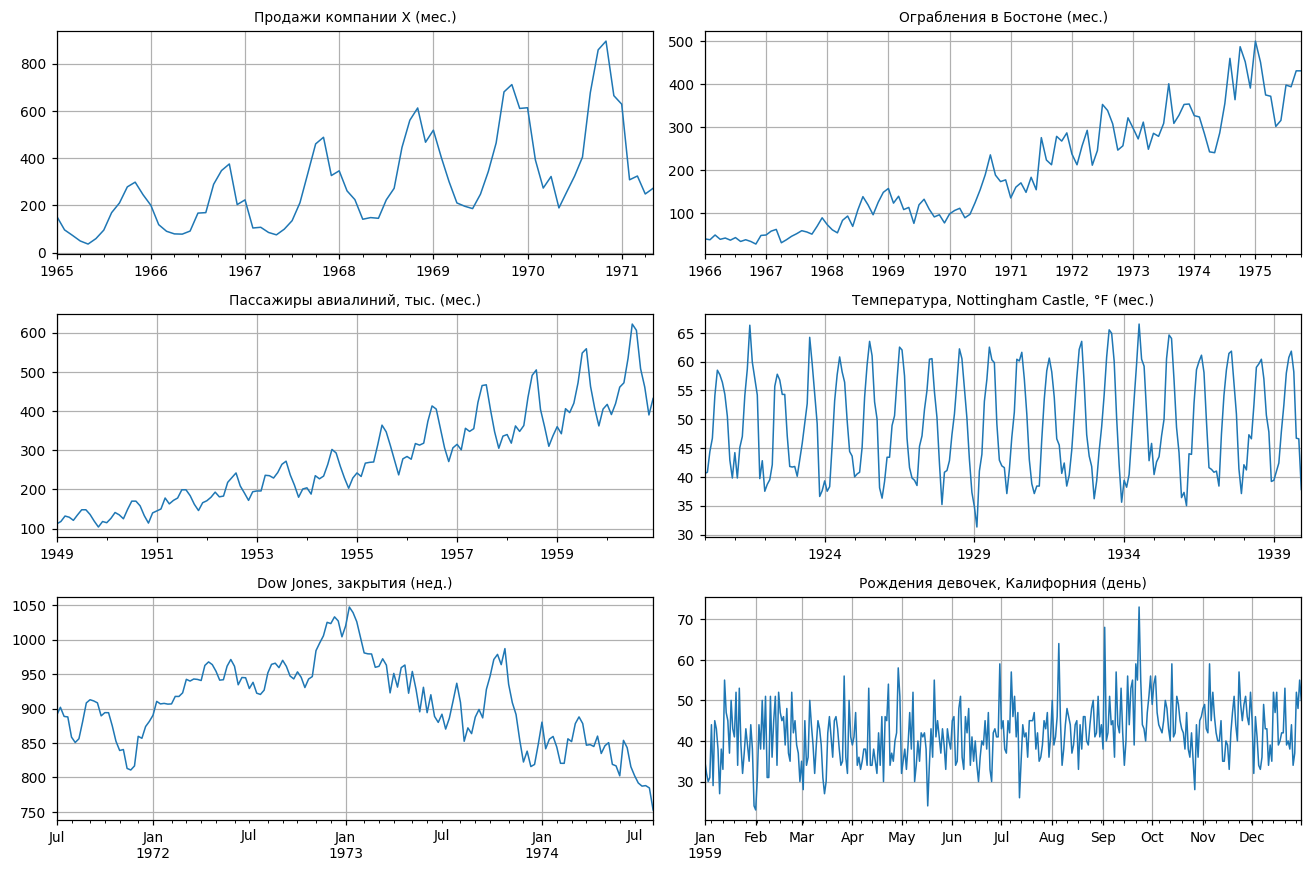

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for ax, (k, s) in zip(axes.ravel(), series_raw.items()):
    s.plot(ax=ax, color='#1f77b4', lw=1)
    ax.set_title(TITLES[k], fontsize=9)
    ax.set_xlabel('')
plt.tight_layout(); plt.show()

In [8]:
rows = []
for k, s in series_raw.items():
    r = stationarity_report(s, season=SEASON[k], verbose=False)
    rows.append({'ряд': k, 'n': r['n'], 'ADF p': round(r['ADF p'], 4),
                 'KPSS p': round(r['KPSS p'], 3), 'r1': round(r['r1'], 3),
                 f'r(сезон)': round(r.get(f"r{SEASON[k]}", np.nan), 3),
                 'порог ACF': round(r['ACF ci'], 3)})
raw_tbl = pd.DataFrame(rows).set_index('ряд')
print('Тесты на исходных рядах (без преобразований):')
raw_tbl

Тесты на исходных рядах (без преобразований):


,n,ADF p,KPSS p,r1,r(сезон),порог ACF
ряд,,,,,,
sales,77,0.9889,0.010,0.871,0.676,0.223
robberies,118,0.9943,0.010,0.928,0.668,0.180
airline,144,0.9919,0.010,0.948,0.760,0.163
temp,240,0.0170,0.100,0.808,0.884,0.127
dowjones,162,0.6225,0.024,0.926,-0.266,0.154
births,365,0.0001,0.010,0.217,0.195,0.103


**Что видно уже здесь.**

- `sales`, `robberies`, `airline` — ADF p ≈ 1, KPSS отвергает стационарность, $r_1 \approx 0.9$ и медленное затухание ACF. Классический нестационарный ряд с трендом.
- `temp` — ADF формально отвергает единичный корень (p = 0.017), но $r_{12} = 0.88$ и не затухает. **ADF здесь вводит в заблуждение**: он проверяет единичный корень на лаге 1, а не сезонную нестационарность. Ряд нестационарен по сезонной компоненте.
- `dowjones` — ADF не отвергает, KPSS отвергает. Согласованный вердикт: нестационарен (случайное блуждание).
- `births` — **тесты противоречат друг другу**: ADF отвергает единичный корень (p = 0.0001), KPSS отвергает стационарность вокруг константы. Такая комбинация — типовой признак *трендовой* стационарности: ряд стационарен вокруг детерминированного тренда, но не вокруг константы. Дифференцировать его нельзя (см. §7).

## 2. Методика: критерии и типовые ошибки

### 2.1 Два теста с противоположными гипотезами

| | KPSS не отвергает (p > 0.05) | KPSS отвергает (p < 0.05) |
|---|---|---|
| **ADF отвергает** (p < 0.05) | ряд **стационарен** | противоречие → чаще всего трендовая стационарность, проверить KPSS с `regression='ct'` |
| **ADF не отвергает** (p > 0.05) | противоречие → мало данных / низкая мощность, решает ACF | ряд **нестационарен** |

Опираться на один ADF нельзя: у него низкая мощность на коротких рядах (n < 100) и он слеп к сезонной нестационарности.

### 2.2 Чек-лист «ряд стационарен»

1. ADF отвергает единичный корень.
2. KPSS не отвергает стационарность.
3. ACF затухает быстро; нет незатухающих пиков на сезонных лагах $s, 2s, 3s$.
4. Дисперсия визуально постоянна во времени.
5. **Нет признаков передифференцирования.**

### 2.3 Передифференцирование

Лишнее дифференцирование не «улучшает» стационарность, а портит ряд: оно вносит в MA-часть корень на единичной окружности, ряд становится неинвертируемым, дисперсия растёт.

Признаки:
- $r_1 \approx -0.5$ и ниже после $\Delta_1$;
- $r_s \approx -0.5$ и ниже после $\Delta_s$;
- дисперсия после дифференцирования **выросла**, а не упала.

Отдельный случай: если сезонность **детерминированная** (стабильная амплитуда и фаза, как у температуры), сезонное дифференцирование почти гарантированно передифференцирует ряд. Правильный инструмент — вычитание сезонных средних / дамми-регрессия. Ниже это показано на `temp` (§6) и `births` (§7).

### 2.4 Чего мы НЕ требуем

Стационарность ≠ белый шум. Остаточная автокорреляция в приведённом ряду — это нормально и даже необходимо: именно её потом моделирует ARMA-часть. Критерий — отсутствие тренда, сезонной нестационарности и единичного корня, а не отсутствие корреляций.

In [9]:
RESULTS = {}   # сюда складываем итоговый стационарный ряд и описание преобразования

def register(key, series, recipe):
    RESULTS[key] = {'series': pd.Series(series).dropna(), 'recipe': recipe}

## 3. `international-airline-passengers` — эталонный случай

Ряд, на котором Бокс и Дженкинс построили «airline model». Разбираем его первым: он даёт шаблон, с которым потом сравниваем остальные.

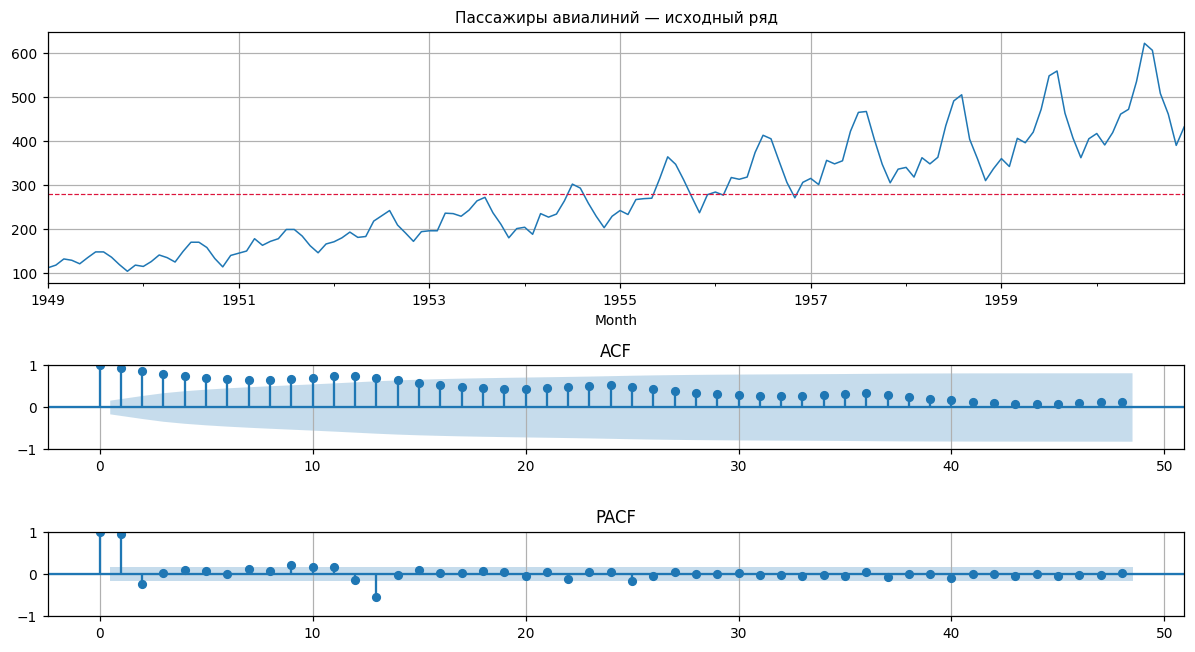

--- airline, исходный ---
  n = 144
  ADF : stat =    0.815   p = 0.9919   ->  единичный корень НЕ отвергнут
  KPSS: stat =    1.651   p = 0.010  (граница таблицы: <0.01)  ->  стационарность ОТВЕРГНУТА
  ACF : r1 = +0.948   r12 = +0.760   r24 = +0.532   (порог значимости ±0.163)


In [10]:
y = series_raw['airline']
tsplot(y, lags=48, title='Пассажиры авиалиний — исходный ряд')
stationarity_report(y, season=12, label='airline, исходный');

Экспоненциальный рост уровня, амплитуда сезонных колебаний растёт вместе с уровнем → сезонность мультипликативная. Проверяем формально.

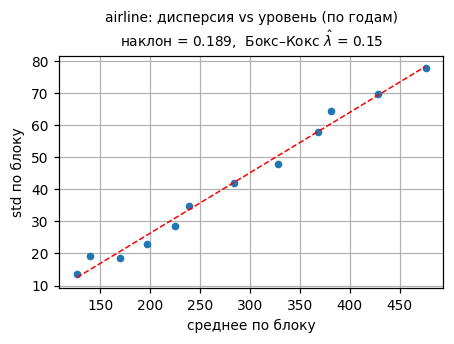

Наклон std~mean = 0.189   |   оценка lambda (MLE) = 0.148
lambda ~ 0  -> логарифм;  lambda ~ 0.5 -> корень;  lambda ~ 1 -> преобразование не нужно


In [11]:
lam = variance_vs_level(y, y.index.year, title='airline: дисперсия vs уровень (по годам)')

Наклон заметно положительный, $\hat\lambda \approx 0.15$ — близко к нулю. Берём **логарифм** ($\lambda = 0$): он интерпретируем (разности логарифмов = темпы прироста) и в данном случае практически совпадает с оптимальным Бокс–Коксом.

### Шаг 1: логарифм

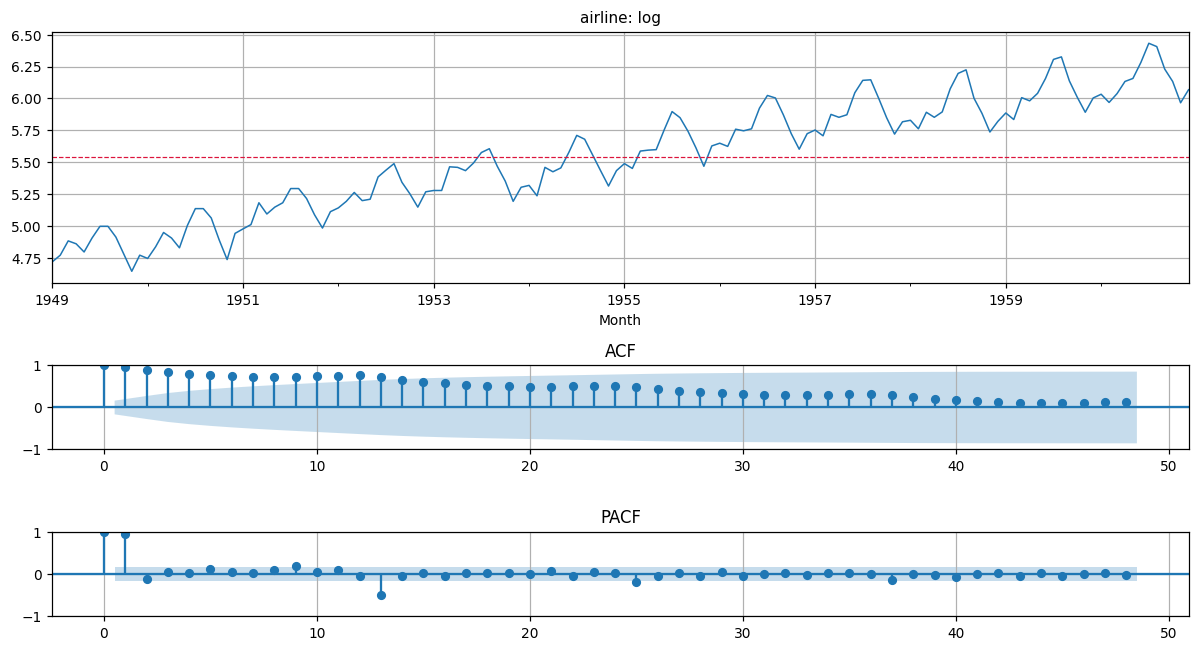

--- airline, log ---
  n = 144
  ADF : stat =   -1.717   p = 0.4224   ->  единичный корень НЕ отвергнут
  KPSS: stat =    1.669   p = 0.010  (граница таблицы: <0.01)  ->  стационарность ОТВЕРГНУТА
  ACF : r1 = +0.954   r12 = +0.762   r24 = +0.520   (порог значимости ±0.163)


In [12]:
y_log = np.log(y)
tsplot(y_log, lags=48, title='airline: log')
stationarity_report(y_log, season=12, label='airline, log');

Амплитуда сезонных колебаний выровнялась. Стационарности нет: ADF p = 0.42, KPSS отвергает, ACF не затухает — остались тренд и сезонность.

### Шаг 2: $\Delta_1$ — убираем тренд

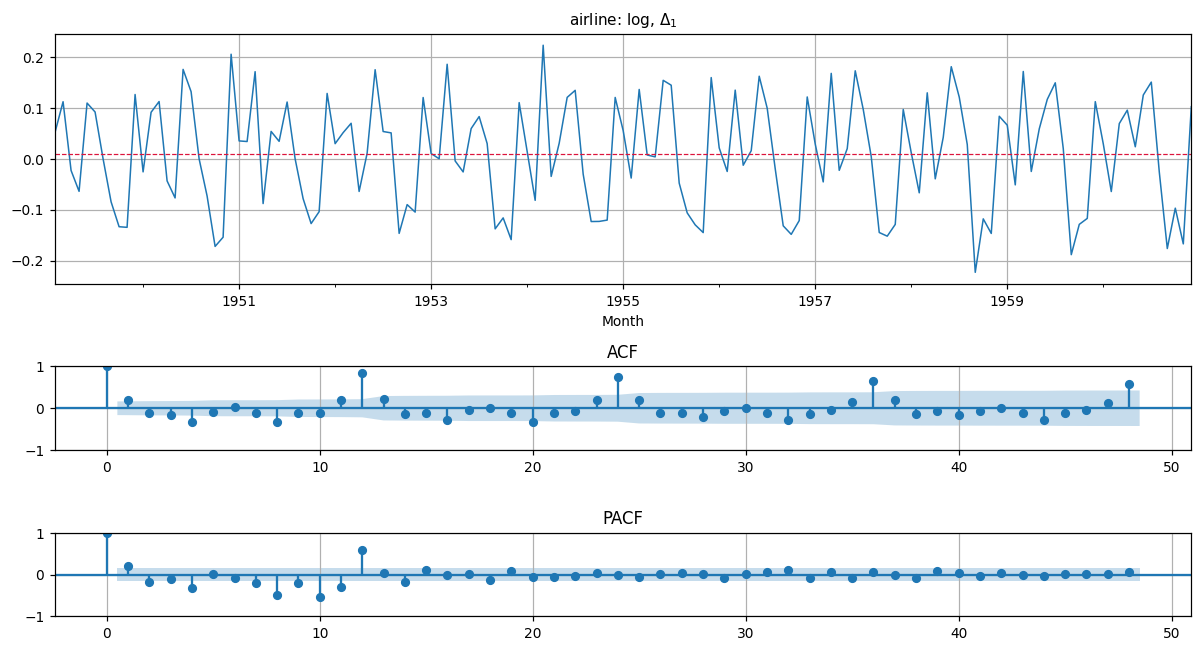

--- airline, log + d1 ---
  n = 143
  ADF : stat =   -2.717   p = 0.0711   ->  единичный корень НЕ отвергнут
  KPSS: stat =    0.038   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = +0.200   r12 = +0.841   r24 = +0.737   (порог значимости ±0.164)


In [13]:
y_log_d1 = diff(y_log, 1)
tsplot(y_log_d1, lags=48, title='airline: log, $\\Delta_1$')
stationarity_report(y_log_d1, season=12, label='airline, log + d1');

Тренд снят, но $r_{12} = +0.84$ при пороге 0.164 — сезонная компонента не только осталась, но и доминирует: ACF показывает незатухающие пики на 12, 24, 36. Это **стохастическая** сезонность (амплитуда пиков не падает) → нужно сезонное дифференцирование.

### Шаг 3: $\Delta_{12}$ — убираем сезонность

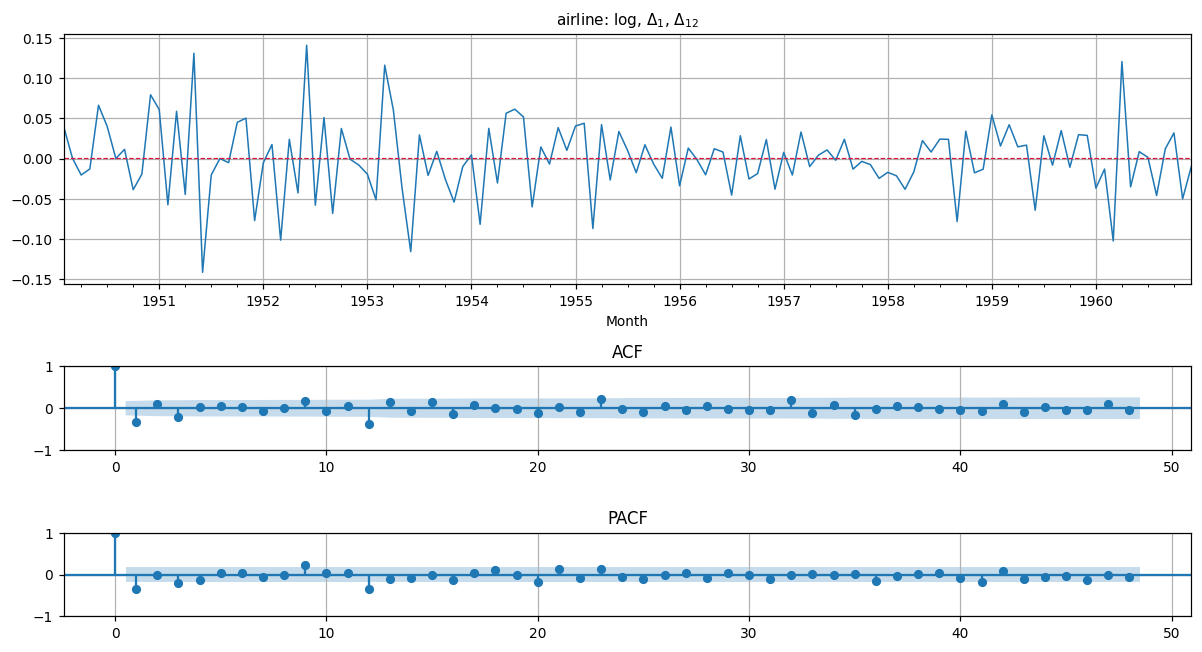

--- airline, log + d1 + d12 ---
  n = 131
  ADF : stat =   -4.443   p = 0.0002   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.073   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = -0.341   r12 = -0.387   r24 = -0.018   (порог значимости ±0.171)

std: log+d1 = 0.1066  ->  log+d1+d12 = 0.0458  (дисперсия упала — передифференцирования нет)


In [14]:
y_air = diff(y_log_d1, 12)
tsplot(y_air, lags=48, title='airline: log, $\\Delta_1$, $\\Delta_{12}$')
stationarity_report(y_air, season=12, label='airline, log + d1 + d12');
print(f'\nstd: log+d1 = {y_log_d1.std():.4f}  ->  log+d1+d12 = {y_air.std():.4f}  (дисперсия упала — передифференцирования нет)')

**Вывод по airline.** ADF p = 0.0002, KPSS > 0.10, ACF затухает мгновенно, дисперсия после сезонного дифференцирования упала более чем вдвое (0.107 → 0.046). Ряд стационарен.

Отрицательные пики $r_1 = -0.34$ и $r_{12} = -0.39$ — это **не** передифференцирование, а сигнатура airline-модели $\text{SARIMA}(0,1,1)(0,1,1)_{12}$: значимый MA(1) и сезонный SMA(1). Признаком передифференцирования было бы $r_1 \le -0.5$ вместе с ростом дисперсии, чего здесь нет.

**Рецепт:** $\nabla_1 \nabla_{12} \log y_t$.

In [15]:
register('airline', y_air, 'log -> $\\Delta_1$ -> $\\Delta_{12}$')

## 4. `monthly-boston-armed-robberies` — когда сезонное дифференцирование НЕ нужно

Ряд похож на airline: сильный рост, месячные данные. Соблазн — применить тот же рецепт. Проверяем, оправдан ли он.

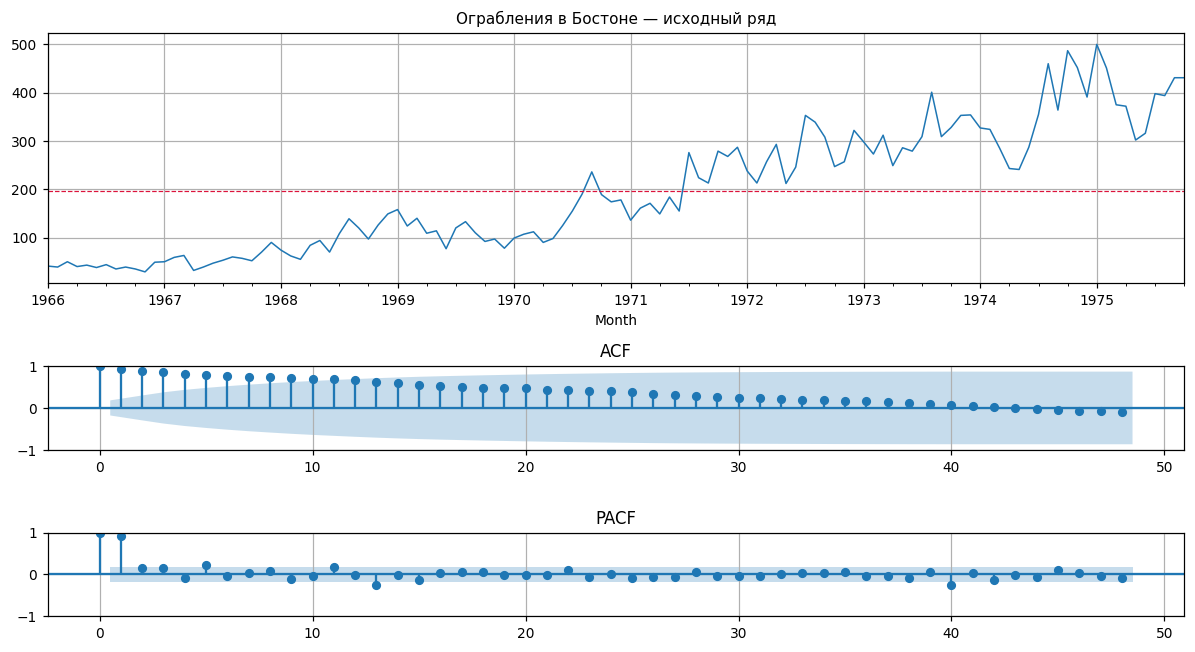

--- robberies, исходный ---
  n = 118
  ADF : stat =    1.001   p = 0.9943   ->  единичный корень НЕ отвергнут
  KPSS: stat =    1.712   p = 0.010  (граница таблицы: <0.01)  ->  стационарность ОТВЕРГНУТА
  ACF : r1 = +0.928   r12 = +0.668   r24 = +0.394   (порог значимости ±0.180)


In [16]:
y = series_raw['robberies']
tsplot(y, lags=48, title='Ограбления в Бостоне — исходный ряд')
stationarity_report(y, season=12, label='robberies, исходный');

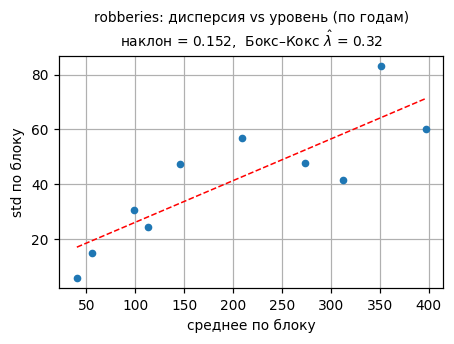

Наклон std~mean = 0.152   |   оценка lambda (MLE) = 0.317
lambda ~ 0  -> логарифм;  lambda ~ 0.5 -> корень;  lambda ~ 1 -> преобразование не нужно

std первой половины ряда: 46.4   второй: 87.0


In [17]:
lam = variance_vs_level(y, y.index.year, title='robberies: дисперсия vs уровень (по годам)')
print(f'\nstd первой половины ряда: {y[:59].std():.1f}   второй: {y[59:].std():.1f}')

Дисперсия второй половины ряда почти вдвое больше первой, $\hat\lambda \approx 0.32$. Логарифм оправдан: он выравнивает std до 0.52 / 0.30.

### Шаг 1: логарифм

std половин после логарифма: 0.527 / 0.304


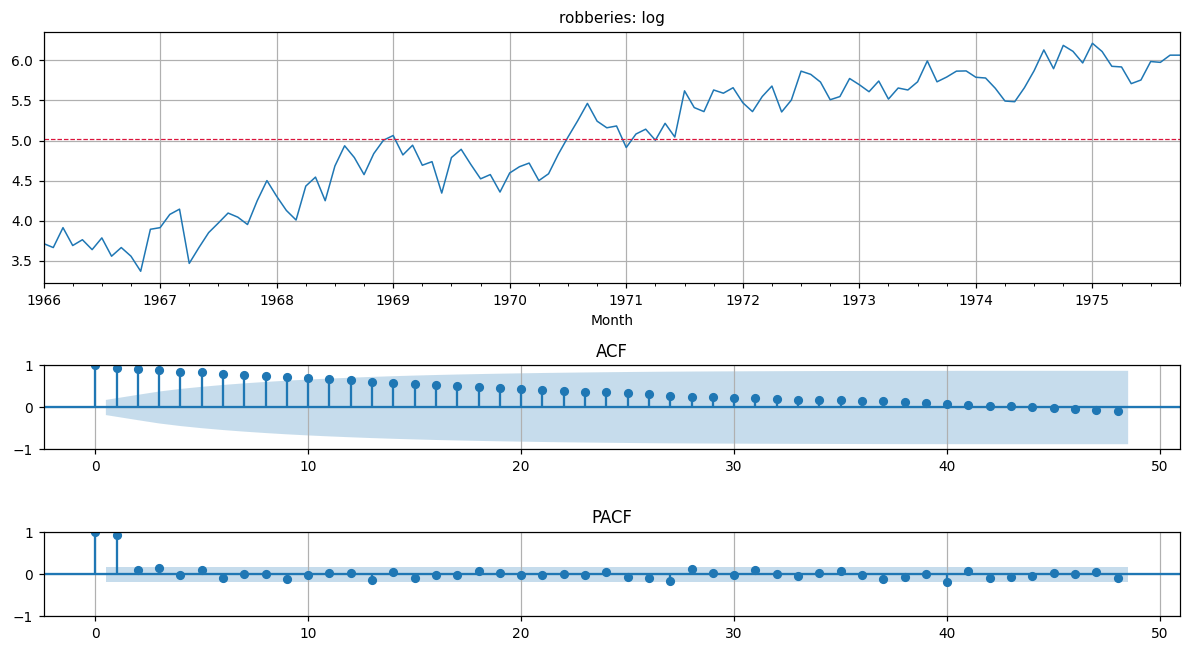

--- robberies, log ---
  n = 118
  ADF : stat =   -2.013   p = 0.2808   ->  единичный корень НЕ отвергнут
  KPSS: stat =    1.695   p = 0.010  (граница таблицы: <0.01)  ->  стационарность ОТВЕРГНУТА
  ACF : r1 = +0.946   r12 = +0.650   r24 = +0.363   (порог значимости ±0.180)


In [18]:
y_log = np.log(y)
print(f'std половин после логарифма: {y_log[:59].std():.3f} / {y_log[59:].std():.3f}')
tsplot(y_log, lags=48, title='robberies: log')
stationarity_report(y_log, season=12, label='robberies, log');

### Шаг 2: $\Delta_1$

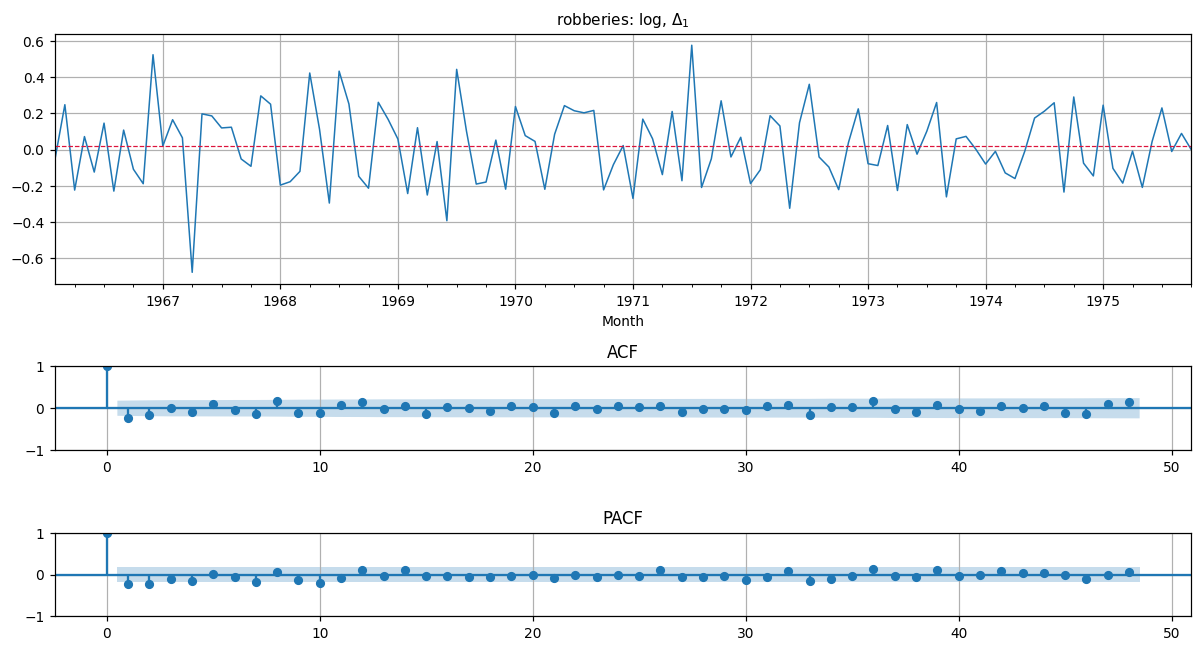

--- robberies, log + d1 ---
  n = 117
  ADF : stat =   -7.602   p = 0.0000   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.090   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = -0.229   r12 = +0.144   r24 = +0.060   (порог значимости ±0.181)


In [19]:
y_rob = diff(y_log, 1)
tsplot(y_rob, lags=48, title='robberies: log, $\\Delta_1$')
stationarity_report(y_rob, season=12, label='robberies, log + d1');

ADF p < 0.0001, KPSS > 0.10, ACF затухает. **Ключевое наблюдение:** $r_{12} = +0.144$ при пороге значимости $\pm 0.181$ — сезонный пик статистически незначим. Высокий $r_{12} = 0.67$ на исходном ряду был артефактом тренда, а не сезонности.

### Проверка: что даст «на всякий случай» ещё и $\Delta_{12}$

In [20]:
y_rob_over = diff(y_rob, 12)
stationarity_report(y_rob_over, season=12, label='robberies, log + d1 + d12  (лишний шаг)');
print(f'\nstd: log+d1 = {y_rob.std():.4f}  ->  log+d1+d12 = {y_rob_over.std():.4f}')
print('Дисперсия выросла, r12 ушёл в -0.43 — сезонное дифференцирование ПЕРЕдифференцировало ряд.')

--- robberies, log + d1 + d12  (лишний шаг) ---
  n = 105
  ADF : stat =   -4.233   p = 0.0006   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.281   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = -0.290   r12 = -0.426   r24 = -0.079   (порог значимости ±0.191)

std: log+d1 = 0.2071  ->  log+d1+d12 = 0.2725
Дисперсия выросла, r12 ушёл в -0.43 — сезонное дифференцирование ПЕРЕдифференцировало ряд.


**Вывод по robberies.** Дисперсия выросла на 30%, а $r_{12}$ упал до $-0.43$ — оба признака передифференцирования. Останавливаемся на $\Delta_1$.

Это прямой контрпример к автоматическому применению схемы airline: одинаковая частота данных и похожая форма графика не означают одинаковой структуры.

**Рецепт:** $\nabla_1 \log y_t$.

In [21]:
register('robberies', y_rob, 'log -> $\\Delta_1$')

## 5. `monthly-sales-of-company-x` — короткий ряд и конфликт тестов

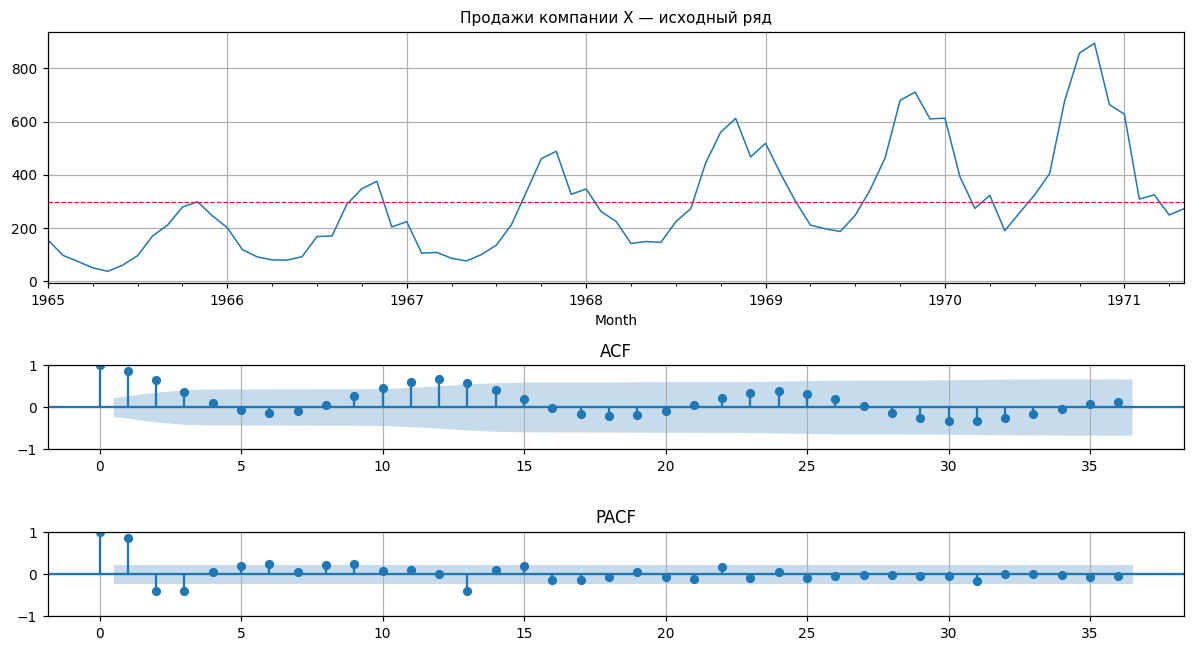

--- sales, исходный ---
  n = 77
  ADF : stat =    0.655   p = 0.9889   ->  единичный корень НЕ отвергнут
  KPSS: stat =    0.852   p = 0.010  (граница таблицы: <0.01)  ->  стационарность ОТВЕРГНУТА
  ACF : r1 = +0.871   r12 = +0.676   r24 = +0.396   (порог значимости ±0.223)


In [22]:
y = series_raw['sales']
tsplot(y, lags=36, title='Продажи компании X — исходный ряд')
stationarity_report(y, season=12, label='sales, исходный');

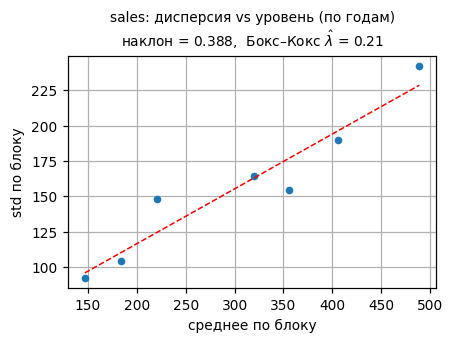

Наклон std~mean = 0.388   |   оценка lambda (MLE) = 0.211
lambda ~ 0  -> логарифм;  lambda ~ 0.5 -> корень;  lambda ~ 1 -> преобразование не нужно

std половин ряда: 118.4 / 204.8


In [23]:
lam = variance_vs_level(y, y.index.year, title='sales: дисперсия vs уровень (по годам)')
print(f'\nstd половин ряда: {y[:38].std():.1f} / {y[38:].std():.1f}')

$\hat\lambda \approx 0.21$, дисперсия второй половины почти вдвое выше. Берём логарифм.

### Шаг 1: логарифм, шаг 2: $\Delta_1$

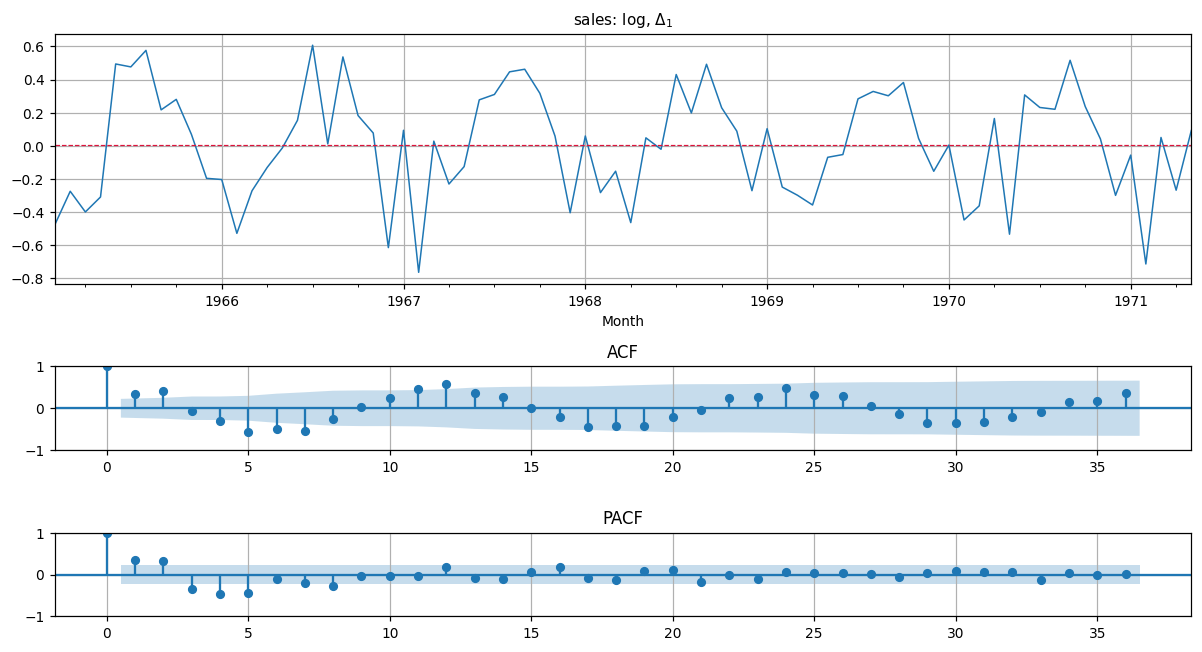

--- sales, log + d1 ---
  n = 76
  ADF : stat =   -3.136   p = 0.0240   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.027   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = +0.346   r12 = +0.592   r24 = +0.491   (порог значимости ±0.225)


In [24]:
y_log = np.log(y)
y_log_d1 = diff(y_log, 1)
tsplot(y_log_d1, lags=36, title='sales: log, $\\Delta_1$')
stationarity_report(y_log_d1, season=12, label='sales, log + d1');

Тренд снят, но $r_{12} = +0.59$ при пороге 0.225 — сезонность значима и не затухает ($r_{24} = +0.49$). Нужен третий шаг. Дальше — два конкурирующих способа.

### Вариант A: сезонное дифференцирование $\Delta_{12}$

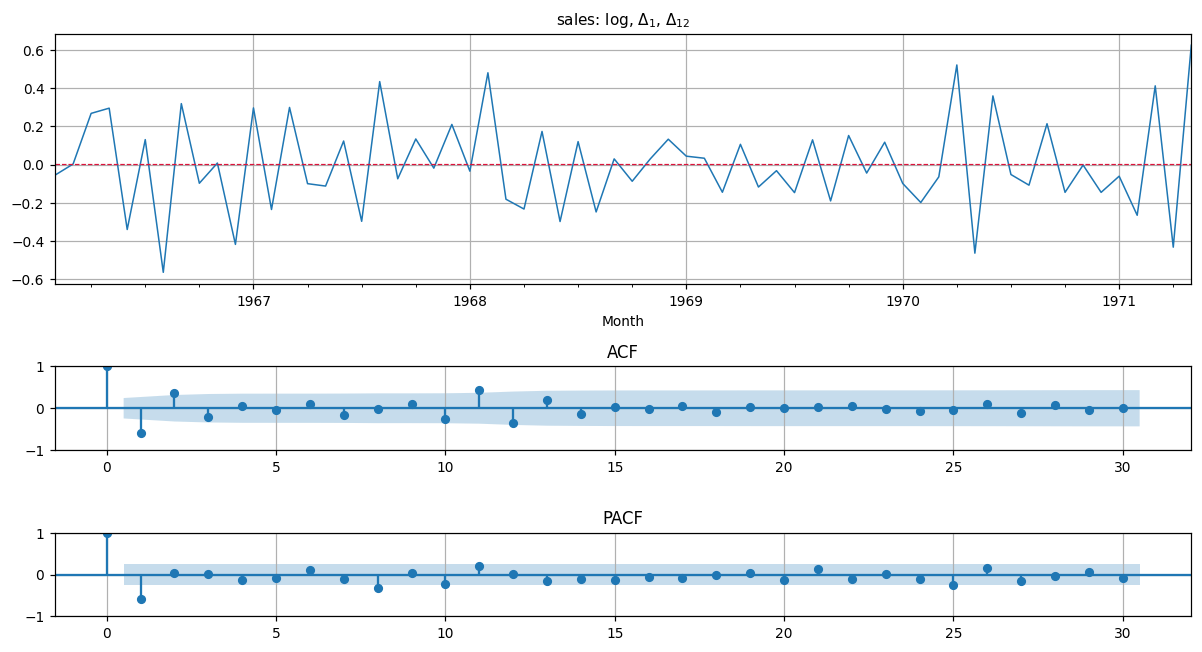

--- sales, log + d1 + d12  (вариант A) ---
  n = 64
  ADF : stat =   -2.316   p = 0.1668   ->  единичный корень НЕ отвергнут
  KPSS: stat =    0.036   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = -0.583   r12 = -0.356   (порог значимости ±0.245)

std: log+d1 = 0.3278  ->  +d12 = 0.2461


In [25]:
y_sales_A = diff(y_log_d1, 12)
tsplot(y_sales_A, lags=30, title='sales: log, $\\Delta_1$, $\\Delta_{12}$')
stationarity_report(y_sales_A, season=12, label='sales, log + d1 + d12  (вариант A)');
print(f'\nstd: log+d1 = {y_log_d1.std():.4f}  ->  +d12 = {y_sales_A.std():.4f}')

Здесь **тесты расходятся**: KPSS не отвергает стационарность (p > 0.10), а ADF не отвергает единичный корень (p ≈ 0.17).

Не выдаю это за стационарность. Разбираемся, что происходит:

- после двух дифференцирований осталось n = 64 наблюдения; мощность ADF на такой длине низкая, а ложное «не отвергаю» — его типовая ошибка;
- $r_1 = -0.58$ ниже порога $-0.5$ — признак передифференцирования, а оно само по себе портит поведение ADF (единичный корень в MA-части «съедает» AR-корень, который ищет тест). Дисперсия при этом упала (0.328 → 0.246), так что признак один, а не два;
- ACF при этом обрывается сразу — незатухающего профиля единичного корня в данных не видно.

То есть ADF-вердикт объясним двумя причинами разом. Проверяю альтернативным способом снятия сезонности, который не тратит наблюдения.

### Вариант B: сезонность как детерминированная компонента (дамми-регрессия)

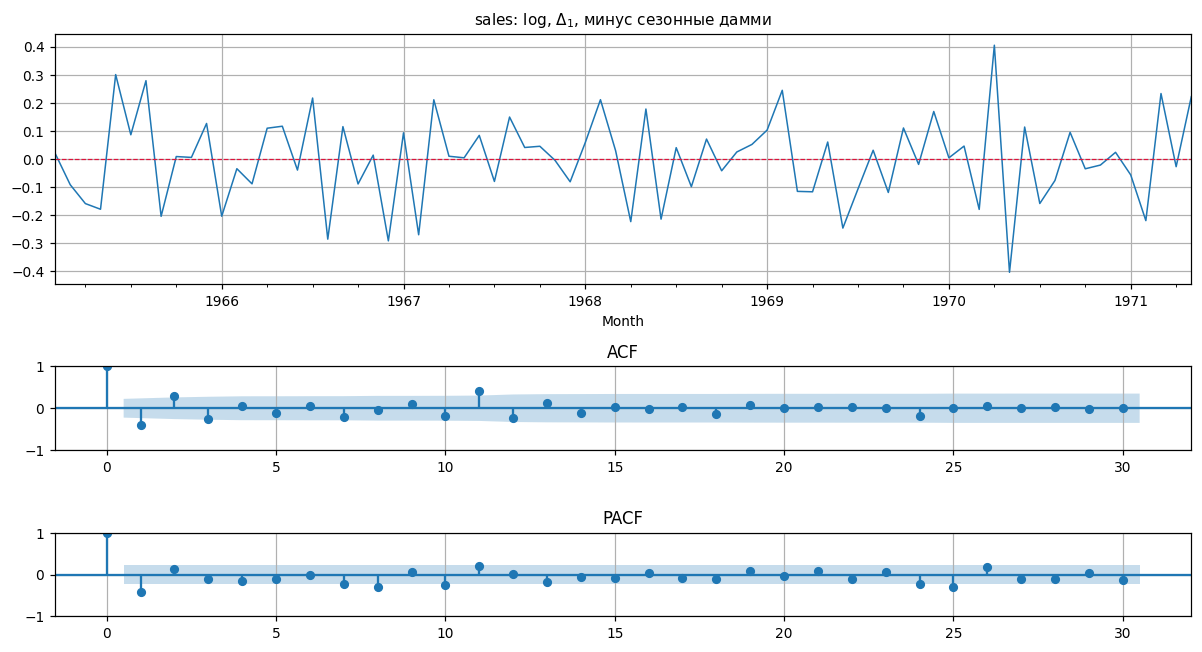

--- sales, log + d1 + сезонные дамми  (вариант B) ---
  n = 76
  ADF : stat =   -2.918   p = 0.0433   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.025   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = -0.410   r12 = -0.225   r24 = -0.175   (порог значимости ±0.225)


In [26]:
y_sales_B, coefs = remove_deterministic(y_log_d1, season=12, trend=False)
tsplot(y_sales_B, lags=30, title='sales: log, $\\Delta_1$, минус сезонные дамми')
stationarity_report(y_sales_B, season=12, label='sales, log + d1 + сезонные дамми  (вариант B)');

Вариант B сохраняет 76 наблюдений вместо 64 — и ADF отвергает единичный корень на уровне 5% (p = 0.043) при KPSS > 0.10 и незначимом $r_{12}$. Оба теста согласны.

**Вывод по sales.** Итоговым беру **вариант B**: $\nabla_1 \log y_t$ минус сезонные дамми. Обоснование — согласие ADF и KPSS, отсутствие потери 12 наблюдений и меньшая степень передифференцирования ($r_1 = -0.41$ против $-0.58$).

[оговорка] Вариант A остаётся допустимым и стандартным для Бокса–Дженкинса; на n = 77 различить стохастическую и детерминированную сезонность статистически надёжно нельзя. Утверждать, что сезонность здесь именно детерминированная, у меня оснований нет — выбор сделан по совокупности диагностик, а не по одному критерию.

**Рецепт:** $\nabla_1 \log y_t$ − сезонные дамми (альтернатива: $\nabla_1 \nabla_{12} \log y_t$).

In [27]:
register('sales', y_sales_B, 'log -> $\\Delta_1$ -> минус сезонные дамми')

## 6. `mean-monthly-air-temperature` — детерминированная сезонность без тренда

Единственный ряд в наборе, где ADF на исходных данных формально «проходит» (p = 0.017). Проверяем, что это значит.

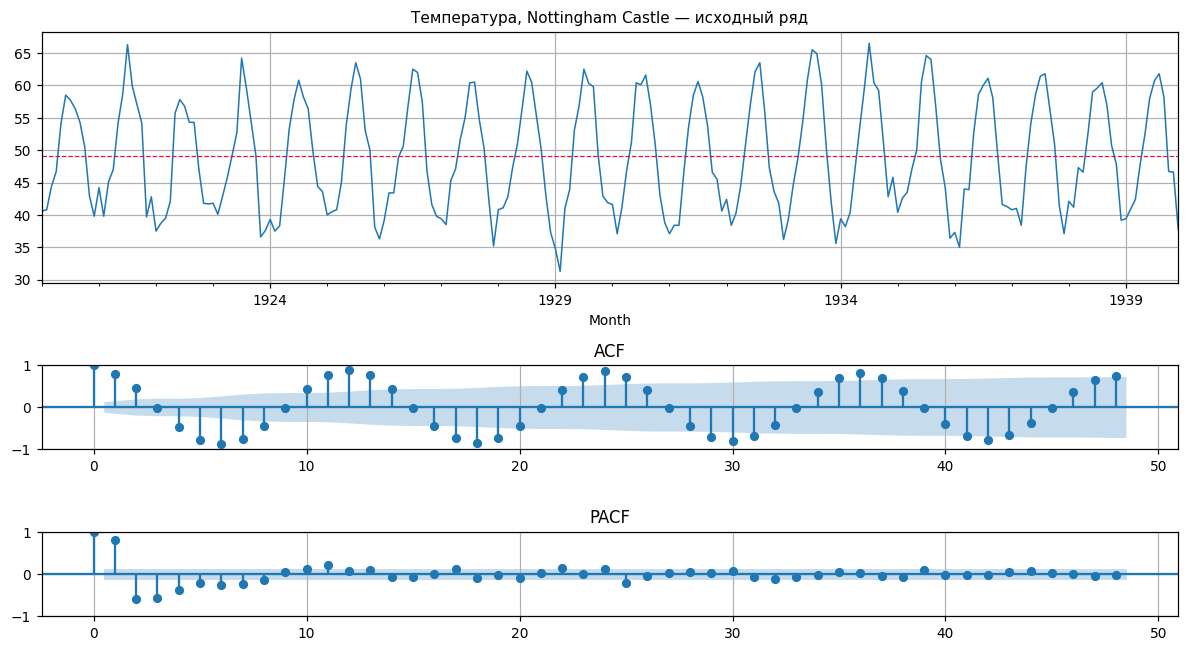

--- temp, исходный ---
  n = 240
  ADF : stat =   -3.255   p = 0.0170   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.044   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = +0.808   r12 = +0.884   r24 = +0.866   (порог значимости ±0.127)


In [28]:
y = series_raw['temp']
tsplot(y, lags=48, title='Температура, Nottingham Castle — исходный ряд')
stationarity_report(y, season=12, label='temp, исходный');

ADF отвергает единичный корень, KPSS не отвергает стационарность — формально оба теста «за». Но ACF даёт $r_{12} = 0.88$, $r_{24} = 0.87$, $r_{36} = 0.81$: **пики не затухают**. Ряд не стационарен, просто оба теста устроены так, что сезонную структуру они не ловят: ADF ищет корень на лаге 1, KPSS смотрит на дрейф уровня.

Это важный частный вывод: **тесты не заменяют коррелограмму**.

### Нужно ли преобразование дисперсии

In [29]:
blocks = (np.arange(len(y)) // 60)
print('std по пятилетним блокам:', [round(v, 2) for v in pd.Series(y.values).groupby(blocks).std()])
print('mean по пятилетним блокам:', [round(v, 2) for v in pd.Series(y.values).groupby(blocks).mean()])
print('\nДисперсия стабильна, уровень не меняется -> Бокс-Кокс не нужен.')
print('Формальная оценка lambda для интервальной шкалы (°F) содержательно не интерпретируется.')

std по пятилетним блокам: [8.01, 8.78, 9.08, 8.56]
mean по пятилетним блокам: [48.69, 48.66, 49.36, 49.45]

Дисперсия стабильна, уровень не меняется -> Бокс-Кокс не нужен.
Формальная оценка lambda для интервальной шкалы (°F) содержательно не интерпретируется.


### Вариант A: сезонное дифференцирование $\Delta_{12}$

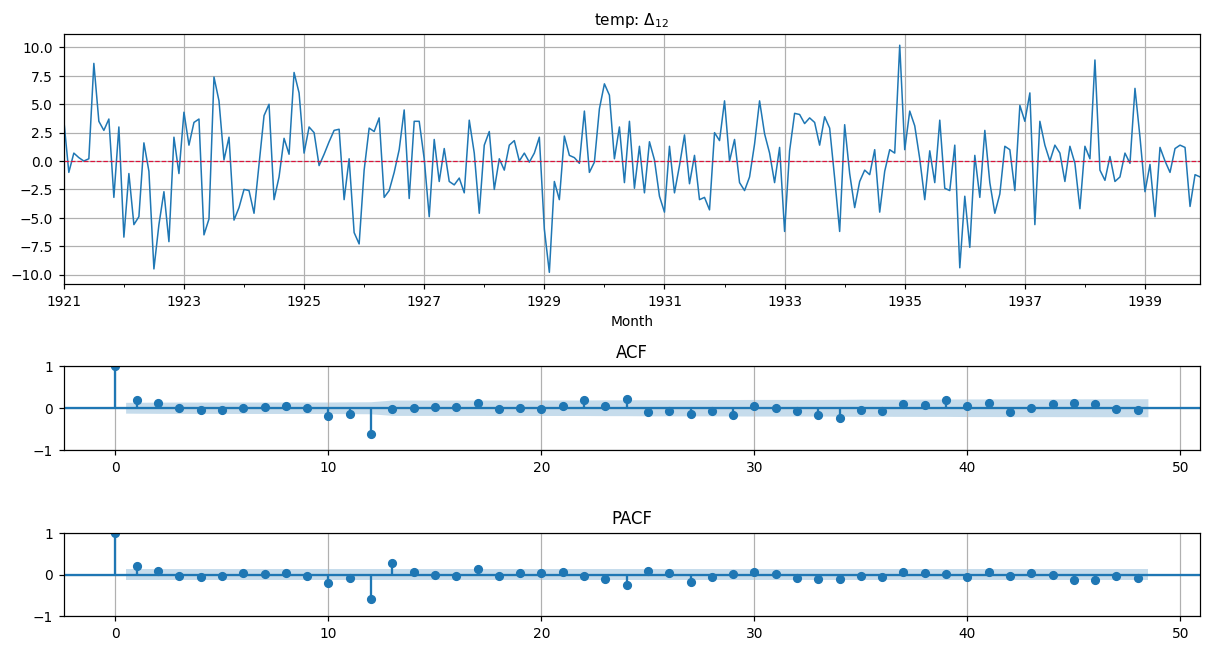

--- temp, d12  (вариант A) ---
  n = 228
  ADF : stat =   -6.073   p = 0.0000   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.027   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = +0.195   r12 = -0.626   r24 = +0.212   (порог значимости ±0.130)

std: исходный = 8.570  ->  d12 = 3.439


In [30]:
y_temp_A = diff(y, 12)
tsplot(y_temp_A, lags=48, title='temp: $\\Delta_{12}$')
stationarity_report(y_temp_A, season=12, label='temp, d12  (вариант A)');
print(f'\nstd: исходный = {y.std():.3f}  ->  d12 = {y_temp_A.std():.3f}')

Тесты проходят, но $r_{12} = -0.63$ — глубокий отрицательный пик ровно на сезонном лаге. Это сигнатура **сезонного передифференцирования**: оператор $\Delta_{12}$ применён к ряду, у которого сезонного единичного корня нет, и внёс в MA-часть корень $\theta_{12} \to -1$.

Механизм: сезонность здесь детерминированная — годовой ход температуры имеет стабильную амплитуду и фазу 20 лет подряд. Для $y_t = S_t + \varepsilon_t$ с постоянным $S_t$ разность $y_t - y_{t-12} = \varepsilon_t - \varepsilon_{t-12}$ — сезонная компонента ушла, но шум продублировался с коэффициентом $-1$.

### Вариант B: вычитание детерминированной сезонной компоненты

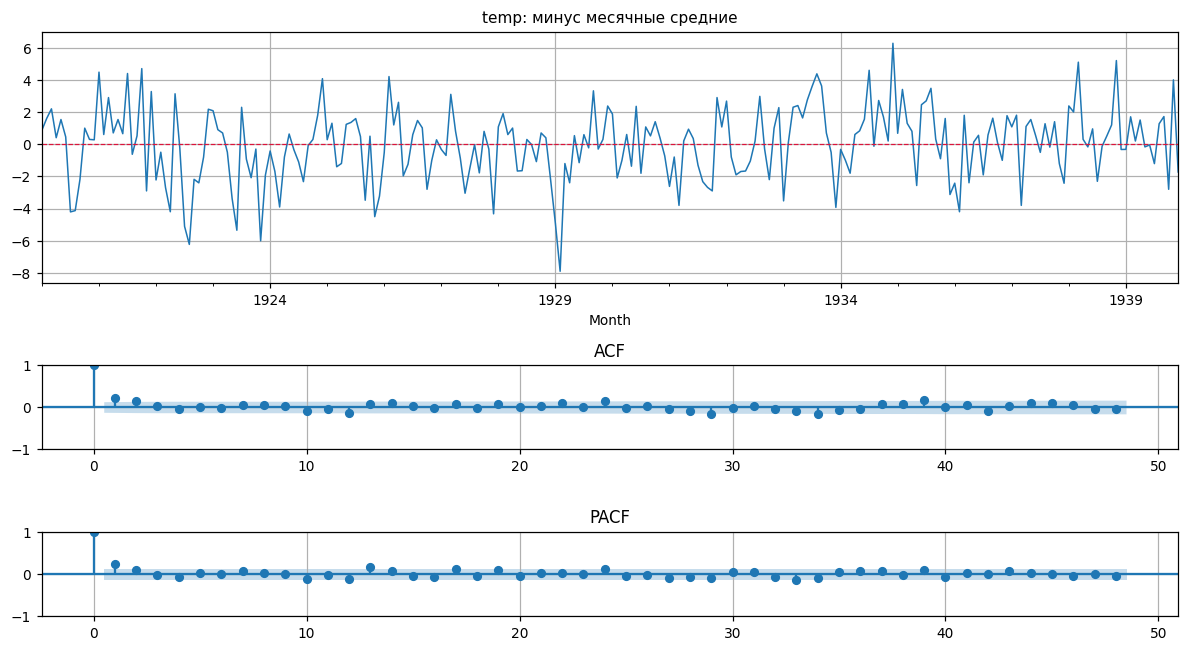

--- temp, минус месячные средние  (вариант B) ---
  n = 240
  ADF : stat =   -8.506   p = 0.0000   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.447   p = 0.057  ->  стационарность НЕ отвергнута
  ACF : r1 = +0.237   r12 = -0.137   r24 = +0.154   (порог значимости ±0.127)

std: исходный = 8.570  ->  минус сезонные средние = 2.259


In [31]:
y_temp_B, coefs = remove_deterministic(y, season=12, trend=False)
tsplot(y_temp_B, lags=48, title='temp: минус месячные средние')
stationarity_report(y_temp_B, season=12, label='temp, минус месячные средние  (вариант B)');
print(f'\nstd: исходный = {y.std():.3f}  ->  минус сезонные средние = {y_temp_B.std():.3f}')

Дисперсия упала с 8.57 до 2.26 (сезонная компонента объясняла ~93% вариации), сохранены все 240 наблюдений, $r_{12} = -0.14$ при пороге 0.127 — на границе, без глубокого отрицательного пика.

[оговорка] KPSS даёт p = 0.057 — близко к 5%. Добавление линейного тренда в регрессию поднимает p выше 0.10, но у меня нет оснований утверждать, что в этих данных есть реальный климатический тренд: на 20 годах это скорее артефакт. Оставляю модель без тренда и фиксирую пограничность результата.

**Вывод по temp.** Итоговый вариант B: вычитание месячных средних. Тренда нет, дифференцирование не требуется вообще.

**Рецепт:** $y_t - \bar{y}_{\text{месяц}(t)}$.

In [32]:
register('temp', y_temp_B, 'минус месячные средние (без дифференцирования)')

## 7. `daily-total-female-births` — трендовая стационарность

На исходном ряду ADF и KPSS дали противоречие (§1). Разбираем его.

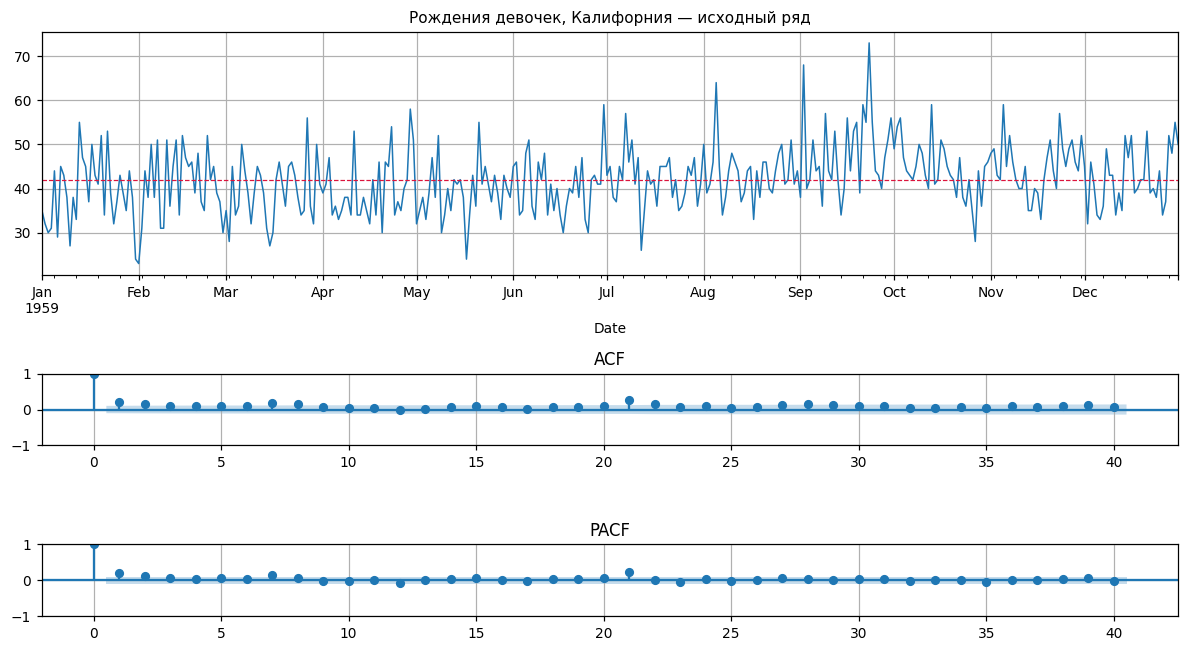

--- births, исходный ---
  n = 365
  ADF : stat =   -4.808   p = 0.0001   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    1.613   p = 0.010  (граница таблицы: <0.01)  ->  стационарность ОТВЕРГНУТА
  ACF : r1 = +0.217   r7 = +0.195   r14 = +0.081   (порог значимости ±0.103)

KPSS вокруг константы (regression="c") : p = 0.010  -> стационарность ОТВЕРГНУТА
KPSS вокруг тренда    (regression="ct"): p = 0.063  -> НЕ отвергнута

среднее первой половины года: 39.76,  второй: 44.18
std   первой половины года: 7.03,  второй: 7.02


In [33]:
y = series_raw['births']
tsplot(y, lags=40, title='Рождения девочек, Калифорния — исходный ряд')
stationarity_report(y, season=7, label='births, исходный');

kp_c = kpss(y.values, regression='c',  nlags='auto')[1]
kp_t = kpss(y.values, regression='ct', nlags='auto')[1]
print(f'\nKPSS вокруг константы (regression="c") : p = {kp_c:.3f}  -> стационарность ОТВЕРГНУТА')
print(f'KPSS вокруг тренда    (regression="ct"): p = {kp_t:.3f}  -> НЕ отвергнута')
print(f'\nсреднее первой половины года: {y[:182].mean():.2f},  второй: {y[183:].mean():.2f}')
print(f'std   первой половины года: {y[:182].std():.2f},  второй: {y[183:].std():.2f}')

Диагноз однозначный: **ADF отвергает единичный корень + KPSS(c) отвергает + KPSS(ct) не отвергает** = ряд стационарен вокруг детерминированного тренда, а не вокруг константы. Среднее растёт (39.8 → 44.2), дисперсия стабильна (7.0 / 7.0) — тренд есть, стохастического корня нет.

Практическое следствие: **дифференцировать нельзя**. $\Delta_1$ применим к стохастическому тренду (случайному блужданию); к детерминированному он применяет лишний оператор.

### Вариант A: $\Delta_1$

In [34]:
y_bir_A = diff(y, 1)
stationarity_report(y_bir_A, season=7, label='births, d1  (вариант A)');
print(f'\nstd: исходный = {y.std():.3f}  ->  d1 = {y_bir_A.std():.3f}')

--- births, d1  (вариант A) ---
  n = 364
  ADF : stat =  -12.625   p = 0.0000   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.187   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = -0.463   r7 = +0.102   r14 = +0.017   (порог значимости ±0.103)

std: исходный = 7.348  ->  d1 = 9.190


$r_1 = -0.46$, дисперсия выросла с 7.34 до 9.18. Оба признака передифференцирования.

### Вариант B: вычитание линейного тренда

коэффициенты регрессии: {'const': np.float64(38.5074), 'trend': np.float64(0.0191)}


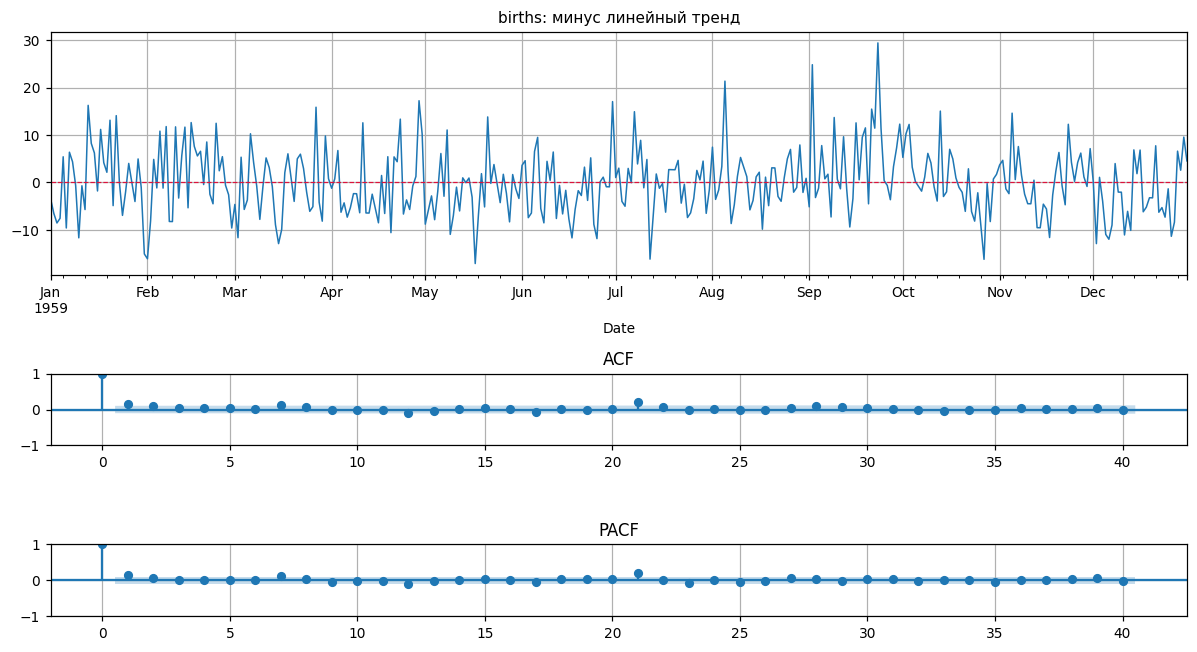

--- births, минус линейный тренд  (вариант B) ---
  n = 365
  ADF : stat =  -16.252   p = 0.0000   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.139   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = +0.156   r7 = +0.140   r14 = +0.015   (порог значимости ±0.103)

std: исходный = 7.348  ->  минус тренд = 7.067


In [35]:
y_bir_B, coefs = remove_deterministic(y, season=None, trend=True)
print('коэффициенты регрессии:', {k: round(v, 4) for k, v in coefs.items()})
tsplot(y_bir_B, lags=40, title='births: минус линейный тренд')
stationarity_report(y_bir_B, season=7, label='births, минус линейный тренд  (вариант B)');
print(f'\nstd: исходный = {y.std():.3f}  ->  минус тренд = {y_bir_B.std():.3f}')

ADF отвергает, KPSS > 0.10, дисперсия не выросла, $r_1 = +0.16$ — передифференцирования нет.

### Остаточный недельный эффект

In [36]:
y_bir_C, coefs = remove_deterministic(y, season=7, trend=True)
r_B = acf(y_bir_B.values, nlags=14, fft=False)
r_C = acf(y_bir_C.values, nlags=14, fft=False)
print(f'после снятия тренда:            r7 = {r_B[7]:+.3f}   (порог ±{1.96/np.sqrt(len(y_bir_B)):.3f})')
print(f'после снятия тренда + дней нед.: r7 = {r_C[7]:+.3f}')
stationarity_report(y_bir_C, season=7, label='births, минус тренд и дни недели');

после снятия тренда:            r7 = +0.140   (порог ±0.103)
после снятия тренда + дней нед.: r7 = +0.095
--- births, минус тренд и дни недели ---
  n = 365
  ADF : stat =  -11.362   p = 0.0000   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.137   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = +0.138   r7 = +0.095   r14 = -0.035   (порог значимости ±0.103)


$r_7 = +0.14$ при пороге $\pm 0.103$ — слабый, но формально значимый недельный эффект. Снятие дамми по дням недели уменьшает его до +0.095 (незначимо), не меняя вердикт тестов.

**Вывод по births.** Итоговый вариант: вычитание линейного тренда и дамми по дням недели. Ряд стационарен; дифференцирование здесь было бы ошибкой.

**Рецепт:** $y_t$ − (линейный тренд + дамми дней недели).

In [37]:
register('births', y_bir_C, 'минус линейный тренд и дамми дней недели')

## 8. `weekly-closings-of-the-dow-jones` — случайное блуждание

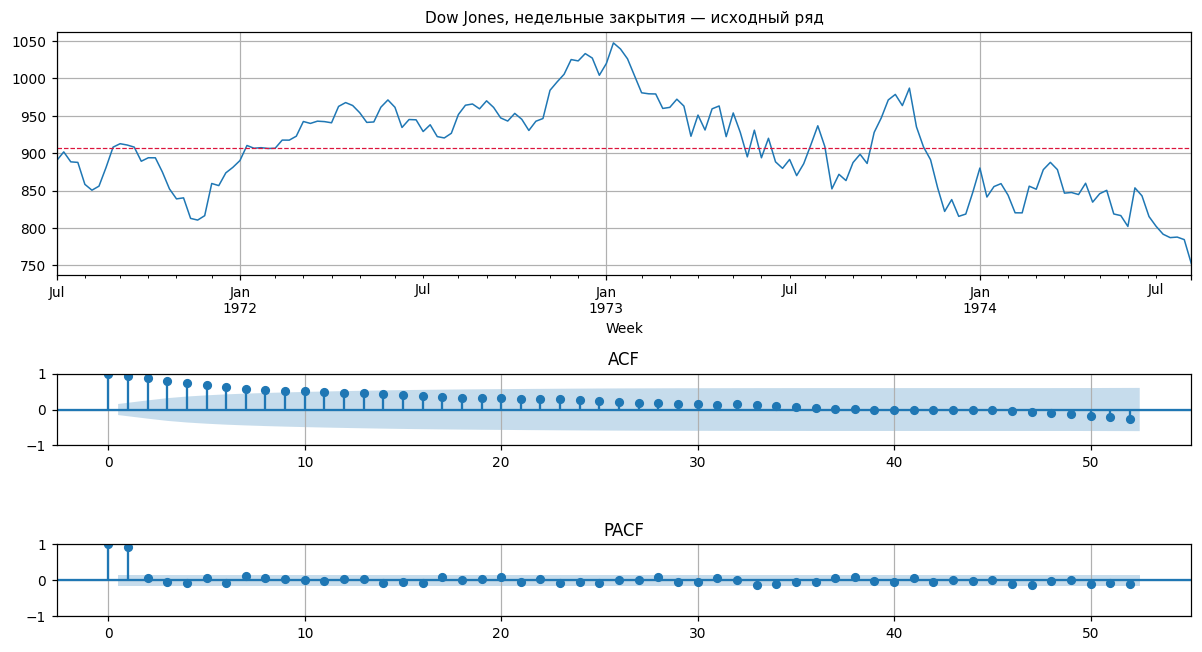

--- dowjones, исходный ---
  n = 162
  ADF : stat =   -1.315   p = 0.6225   ->  единичный корень НЕ отвергнут
  KPSS: stat =    0.583   p = 0.024  ->  стационарность ОТВЕРГНУТА
  ACF : r1 = +0.926   r52 = -0.266   (порог значимости ±0.154)


In [38]:
y = series_raw['dowjones']
tsplot(y, lags=52, title='Dow Jones, недельные закрытия — исходный ряд')
stationarity_report(y, season=52, label='dowjones, исходный');

In [39]:
lam = boxcox_normmax(y.values, method='mle')
blocks = (np.arange(len(y)) // 54)
print(f'оценка lambda (MLE) = {lam:.3f}  -> формально преобразование не требуется')
print('std по третям ряда:', [round(v, 2) for v in pd.Series(y.values).groupby(blocks).std()])

оценка lambda (MLE) = 1.133  -> формально преобразование не требуется
std по третям ряда: [41.83, 44.1, 52.09]


$\hat\lambda \approx 1.1$ — Бокс–Кокс формально не нужен. Тем не менее беру логарифм: для ценового ряда $\Delta_1 \log P_t$ — это лог-доходность, величина с содержательным смыслом и стабильной дисперсией, тогда как $\Delta_1 P_t$ измеряется в пунктах и зависит от уровня индекса. Практический результат тестов при этом одинаков (проверено ниже).

### Шаг 1: логарифм, шаг 2: $\Delta_1$

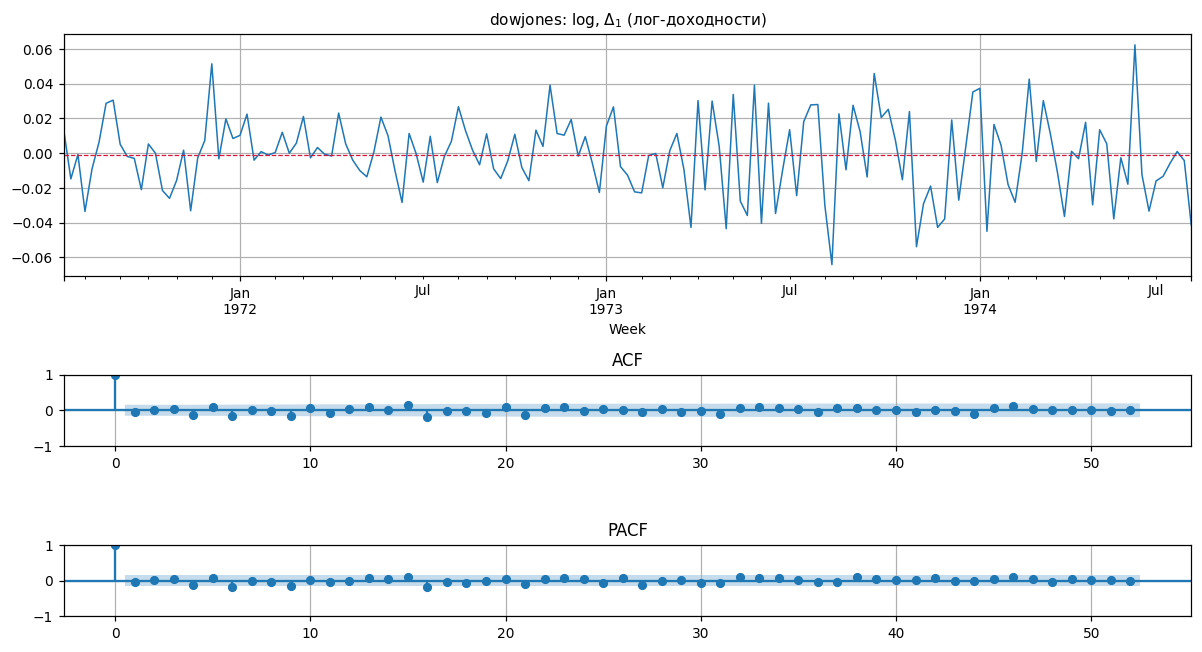

--- dowjones, log + d1 ---
  n = 161
  ADF : stat =  -12.996   p = 0.0000   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.199   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = -0.042   r52 = +0.014   (порог значимости ±0.154)

--- dowjones, d1 без логарифма (для сравнения) ---
  n = 161
  ADF : stat =  -13.025   p = 0.0000   ->  единичный корень ОТВЕРГНУТ
  KPSS: stat =    0.185   p = 0.100  (граница таблицы: >0.10)  ->  стационарность НЕ отвергнута
  ACF : r1 = -0.042   r52 = +0.003   (порог значимости ±0.154)


In [40]:
y_log = np.log(y)
y_dj = diff(y_log, 1)
tsplot(y_dj, lags=52, title='dowjones: log, $\\Delta_1$ (лог-доходности)')
stationarity_report(y_dj, season=52, label='dowjones, log + d1');

print()
stationarity_report(diff(y, 1), season=52, label='dowjones, d1 без логарифма (для сравнения)');

**Вывод по dowjones.** ADF p < 0.0001, KPSS > 0.10, $r_1 = -0.04$ — автокорреляция практически отсутствует. Одного обычного дифференцирования достаточно.

Сезонности нет и не должно быть: недельные котировки годового цикла не имеют, $r_{52}$ незначим. Сезонное дифференцирование $\Delta_{52}$ здесь стоило бы 52 наблюдения из 162 и не дало бы ничего.

Исходный ряд — почти чистое случайное блуждание, $\text{ARIMA}(0,1,0)$: приращения близки к белому шуму. Это согласуется с гипотезой эффективного рынка в слабой форме.

**Рецепт:** $\nabla_1 \log y_t$.

In [41]:
register('dowjones', y_dj, 'log -> $\\Delta_1$')

## 9. Итоги

In [42]:
order = ['sales', 'robberies', 'airline', 'temp', 'dowjones', 'births']
rows = []
for k in order:
    raw = series_raw[k]
    st  = RESULTS[k]['series']
    r0 = stationarity_report(raw, season=SEASON[k], verbose=False)
    r1 = stationarity_report(st,  season=SEASON[k], verbose=False)
    rows.append({
        'ряд': k,
        'преобразование': RESULTS[k]['recipe'].replace('$', '').replace('\\Delta', 'D'),
        'ADF p (было)':  round(r0['ADF p'], 4),
        'ADF p (стало)': round(r1['ADF p'], 4),
        'KPSS p (было)': round(r0['KPSS p'], 3),
        'KPSS p (стало)':round(r1['KPSS p'], 3),
        'n': r1['n'],
        'r1': round(r1['r1'], 3),
        'r(сезон)': round(r1.get(f"r{SEASON[k]}", np.nan), 3),
    })
summary = pd.DataFrame(rows).set_index('ряд')
summary

,преобразование,ADF p (было),ADF p (стало),KPSS p (было),KPSS p (стало),n,r1,r(сезон)
ряд,,,,,,,,
sales,log -> D_1 -> минус сезонные дамми,0.9889,0.0433,0.010,0.100,76,-0.410,-0.225
robberies,log -> D_1,0.9943,0.0000,0.010,0.100,117,-0.229,0.144
airline,log -> D_1 -> D_{12},0.9919,0.0002,0.010,0.100,131,-0.341,-0.387
temp,минус месячные средние (без дифференцирования),0.0170,0.0000,0.100,0.057,240,0.237,-0.137
dowjones,log -> D_1,0.6225,0.0000,0.024,0.100,161,-0.042,0.014
births,минус линейный тренд и дамми дней недели,0.0001,0.0000,0.010,0.100,365,0.138,0.095


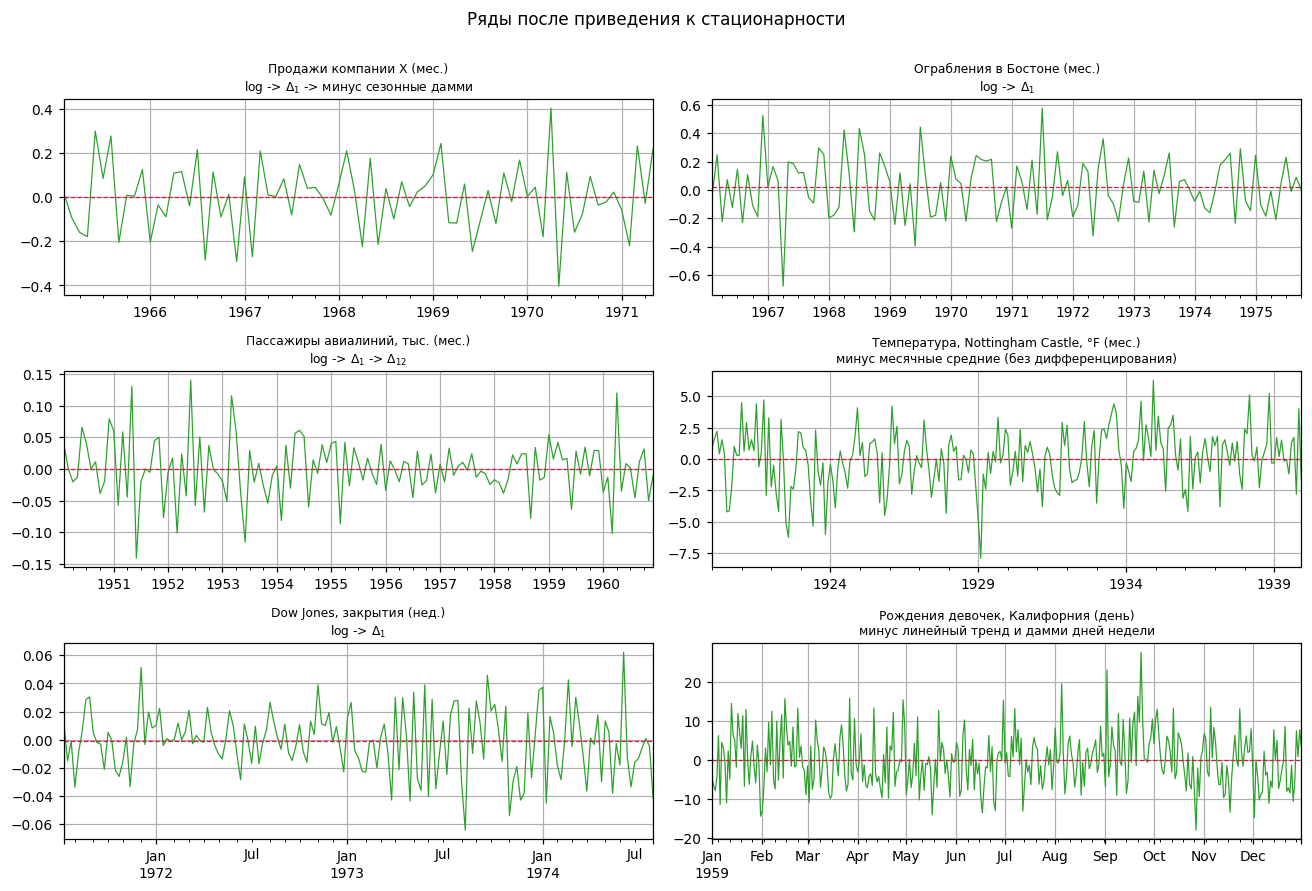

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for ax, k in zip(axes.ravel(), order):
    s = RESULTS[k]['series']
    s.plot(ax=ax, color='#2ca02c', lw=0.8)
    ax.axhline(s.mean(), color='crimson', lw=0.8, ls='--')
    ax.set_title(f'{TITLES[k]}\n{RESULTS[k]["recipe"]}', fontsize=8)
    ax.set_xlabel('')
plt.suptitle('Ряды после приведения к стационарности', y=1.005, fontsize=11)
plt.tight_layout(); plt.show()

### Итоговая таблица преобразований

| Ряд | Бокс–Кокс | Сезонность | Тренд | Итог |
|---|---|---|---|---|
| `sales` | log | сезонные дамми | $\Delta_1$ | стационарен |
| `robberies` | log | не требуется | $\Delta_1$ | стационарен |
| `airline` | log | $\Delta_{12}$ | $\Delta_1$ | стационарен |
| `temp` | не требуется | месячные средние | не требуется | стационарен |
| `dowjones` | log (по смыслу) | не требуется | $\Delta_1$ | стационарен |
| `births` | не требуется | дамми дней недели | линейный тренд (МНК) | стационарен |

### Что показал разбор

**Одинаковый рецепт ко всем рядам не применяется.** Стандартная схема «лог + $\Delta_1$ + $\Delta_{12}$» подошла ровно одному ряду из шести — `airline`. Для `robberies` она добавляет лишнее сезонное дифференцирование, для `temp` и `births` дифференцирование вообще не нужно.

**Ключевое различие — детерминированная или стохастическая компонента:**

| | Диагностика | Инструмент |
|---|---|---|
| стохастический тренд | ADF не отвергает, KPSS(c) отвергает | $\Delta_1$ |
| детерминированный тренд | ADF отвергает, KPSS(c) отвергает, KPSS(ct) не отвергает | МНК-детренд |
| стохастическая сезонность | $r_s$ не затухает на $s, 2s, 3s$ после $\Delta_1$ | $\Delta_s$ |
| детерминированная сезонность | стабильная амплитуда и фаза, $\Delta_s$ даёт $r_s \approx -0.5$ | сезонные средние / дамми |

**ADF и KPSS недостаточно.** `temp` проходит оба теста на исходных данных, будучи явно нестационарным по сезонной компоненте. Коррелограмма обязательна.

**Передифференцирование — реальная ошибка, а не теоретическая.** Три ряда из шести (`robberies`, `temp`, `births`) дают её при механическом применении стандартной схемы. Контроль — рост дисперсии после шага и $r \le -0.5$ на соответствующем лаге.

**Нерешённое.** На `sales` (n = 77) выбор между стохастической и детерминированной сезонностью статистически не разрешается: ADF и KPSS дают противоположные вердикты, и различить два механизма на 6 годах данных нельзя. Выбранный вариант обоснован совокупностью диагностик, но не доказан.